In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "monospace"

# Color Palette
NAVY: str = "#223D5A"
SEAFOAM: str = "#2B7371"
OCHRE: str = "#BBA358"

TESTS: str = "/home/abhans/Projects/acraft/tests"
TEST: int = max(os.listdir(TESTS), key=int)
PATH: str = f"{TESTS}/{TEST}"
METRICS: str = f"{PATH}/metrics.csv"
print(f"Test: {TEST}")

Test: 02


In [22]:
data = pd.read_csv(METRICS)
iterations = data["Iter"]

In [23]:
# ------------------------ PLOT CONFIGURATIONS ------------------------
# (Axis Index, title, Key from Data, Color)
configPlot = [
    (0, "Average Reward", "Average Reward", NAVY, True),
    (1, "Policy Loss (PPO)", "Loss:Policy", NAVY, False),
    (2, "Value Loss (Critic)","Loss:Value", SEAFOAM, True),
    (3, "Policy Entropy", "Entropy", OCHRE, False),
    (4, "Explained Variance", "Explained Variance", SEAFOAM, False),
    (5, "Moving Average Reward", "Moving Average Reward", OCHRE, True),
]

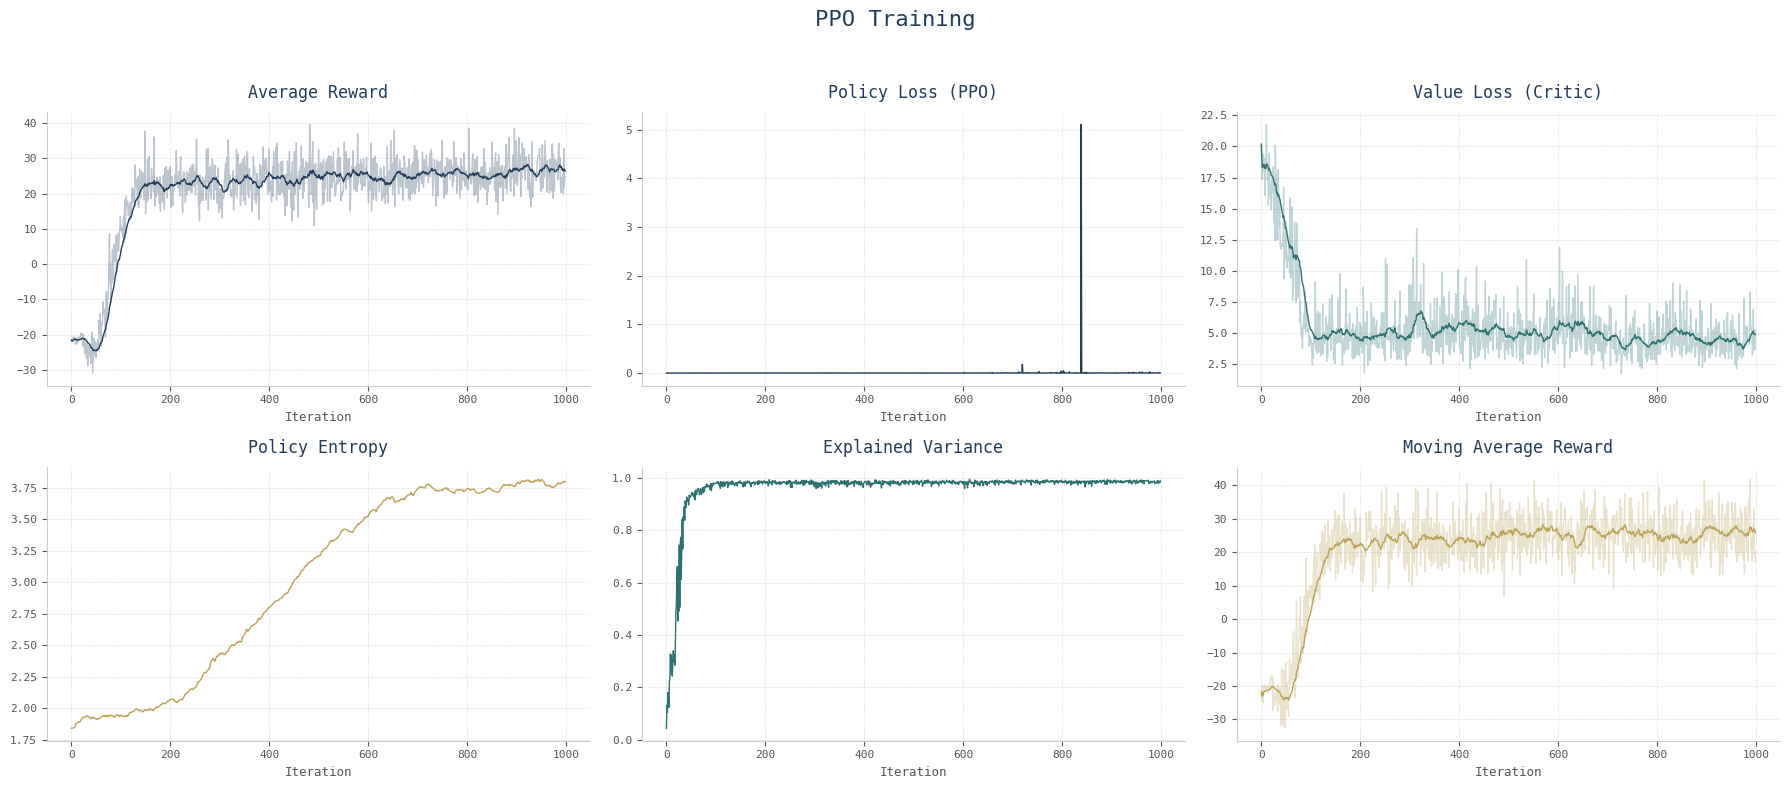

[SYSTEM] Figure saved to: /home/abhans/Projects/acraft/tests/02/results.png


In [26]:
# Set up the matplotlib figure (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("PPO Training", fontsize=16, color=NAVY, fontweight="normal", y=0.98)

# Flatten axes array for easy iteration
axs = axs.flatten()

# ------------------------ DRAW PLOTS ------------------------
for idx, title, key, color, smooth in configPlot:
    ax = axs[idx]
    
    # Plot the smoothed curve if requested, otherwise plot raw data
    if smooth:
        # ---- Raw data with low opacity ----
        ax.plot(iterations, data[key], color=color, linewidth=1, alpha=0.3)
        smoothed = data[key].rolling(window=20, min_periods=1).mean()
        # ---- Smoothed curve ----
        ax.plot(iterations, smoothed, color=color, linewidth=1)
    else:
        ax.plot(iterations, data[key], color=color, linewidth=1)
    
    # Styling
    ax.set_title(title, fontsize=12, color=NAVY, pad=10)
    ax.set_xlabel("Iteration", fontsize=9, color="#555555")
    ax.tick_params(colors="#555555", labelsize=8)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#CCCCCC")
    ax.spines['bottom'].set_color("#CCCCCC")

# ------------------------ CLEANUP EMPTY SUBPLOT ------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"{PATH}/results.png", dpi=900)
print(f"[SYSTEM] Figure saved to: {f'{PATH}/results.png'}")